# Input Testing

✓ Model created: ViT
  Total parameters: 5,381,477

FLOOD INFERENCE ENGINE READY
  Device         : cuda
  Model          : ViT
  Spatial patches: 6,480 (Manila mask)
  Patch shape    : (4, 4, 3)
  Rain range     : [0.0000, 189.8531]
  Num classes    : 5
  Batch size     : 64
  Manila indices : 6,480 patches indexed

  Hyperparameters (from tuning):
    embed_dim:        384
    num_heads:        16
    num_layers:       5
    mlp_ratio:        1.50
    dropout:          0.0000
    rainfall_hidden:  32
    lr:               0.000014
    weight_decay:     0.000052
    ce_weight:        1.0000
    batch_size:       64

  Tuning Results:
    Best trial:       3
    Total trials:     10
    Tuning F1:        0.6578
    Validation F1:    0.4954

  Checkpoint Info:
    Best fold:        1
    Checkpoint dir:   checkpoints

✓ Inference engine initialized

[run_inference] Starting: front-loaded_10mm
Predicting 6,480 patches (batch_size=64)...
  checkmark 320/6,480 patches
  checkmark 640/6,480

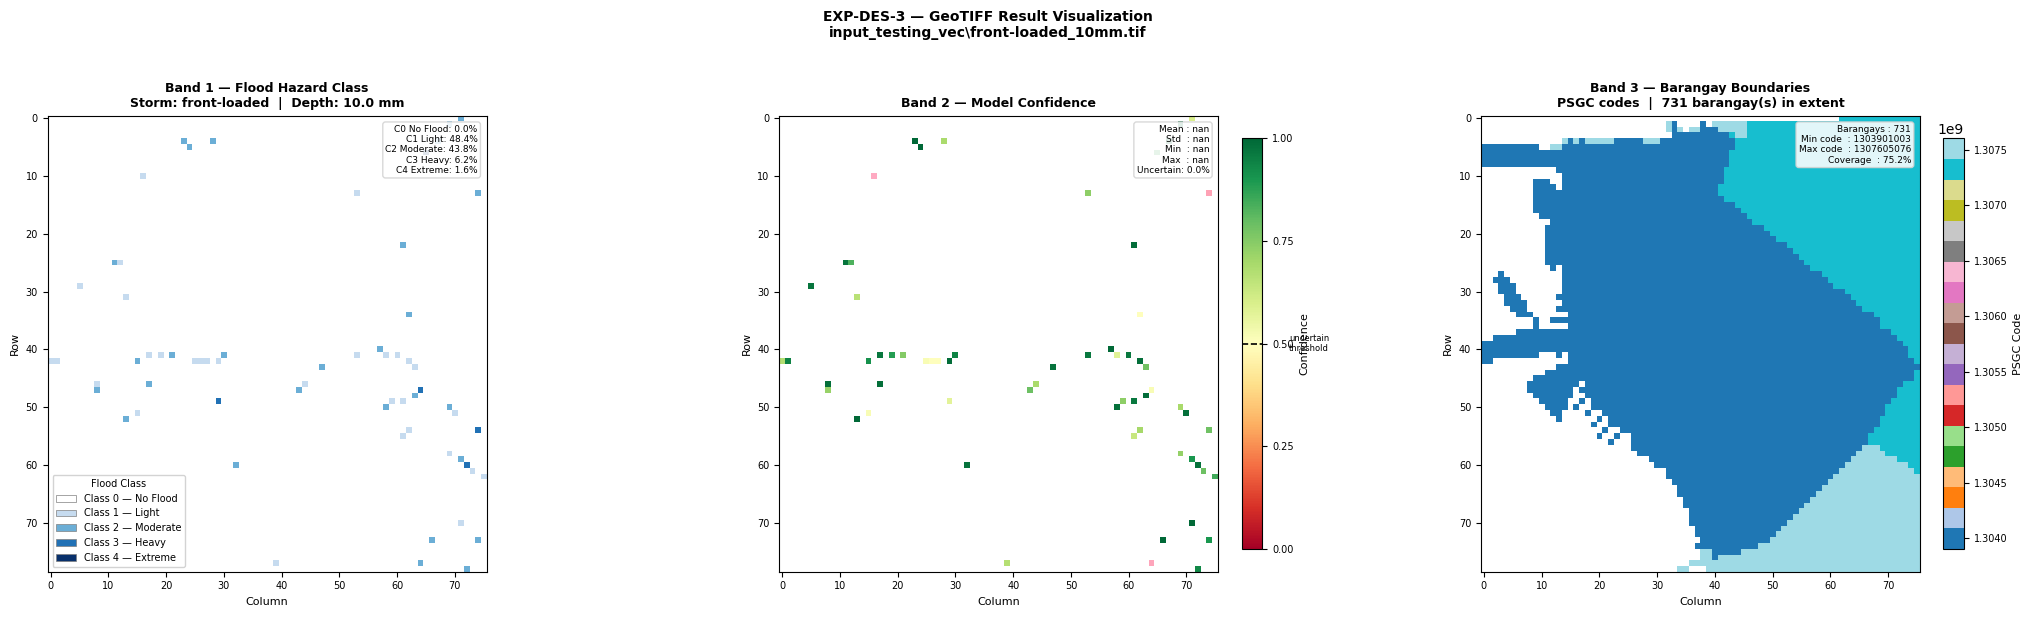

✓ Results saved to input_testing_vec


In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import rasterio
import json
import os
from rasterio.transform import Affine
from pathlib import Path

from config import TrainConfig, ModelConfig
from model_config import make_model
from inference import FloodInferenceEngine
from inference import run_inference

cfg  = TrainConfig()
mcfg = ModelConfig()
PATCH_SIZE = mcfg.patch_size
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ── Spatial data ──────────────────────────────────────────────────────────────
data = np.load(cfg.output_dir / 'spatial_data.npz')
X_full = data['spatial']
manila_patch_indices = data['manila_patch_indices']
rain_min = float(data['rain_min'].item())
rain_max = float(data['rain_max'].item())
N_H = int(data['n_h'].item())
N_W = int(data['n_w'].item())

# ── GeoTIFF transform ────────────────────────────────────────────────────────
with rasterio.open('COP-30m-GMM/greater_mm_bbox_dem_cop.tif') as src:
    t = src.transform
    dem_crs = src.crs
dem_transform = Affine(t.a * PATCH_SIZE, 0, t.c, 0, t.e * PATCH_SIZE, t.f)


# ── Model ─────────────────────────────────────────────────────────────────────
inference_config_path = cfg.output_dir / 'inference_config.json'
with open(inference_config_path, 'r') as f:
    inference_cfg = json.load(f)
    
model_cfg = ModelConfig(
    in_channels=inference_cfg.get('in_channels'),
    patch_size=inference_cfg.get('patch_size'),
    num_classes=inference_cfg.get('num_classes'),
    embed_dim=inference_cfg['embed_dim'],                    
    num_heads=inference_cfg['num_heads'],                   
    num_layers=inference_cfg['num_layers'],                 
    mlp_ratio=inference_cfg['mlp_ratio'],                    
    dropout=inference_cfg['dropout'],                       
    learnable_pos_enc=inference_cfg.get('learnable_pos_enc', True),
    rainfall_method=inference_cfg.get('rainfall_method', 'hybrid'),
    num_timesteps=inference_cfg.get('num_timesteps', 13),
    conditioning_dim=inference_cfg.get('conditioning_dim', 19),
    rainfall_hidden=inference_cfg['rainfall_hidden'],        
)
# Create model
model = make_model(model_cfg).to(device)
print(f"✓ Model created: {type(model).__name__}")
print(f"  Total parameters: {sum(p.numel() for p in model.parameters()):,}")

# Get best fold and checkpoint from inference config
best_fold = inference_cfg['best_fold']
checkpoint_dir = Path(inference_cfg['checkpoint_dir'])
best_ckpt = checkpoint_dir / f'fold_{best_fold}' / 'best_model.pt'
ckpt = torch.load(best_ckpt, map_location=device, weights_only=False)
model.load_state_dict(ckpt['model_state_dict'])
model.eval()

# ── Inference engine ──────────────────────────────────────────────────────────
engine = FloodInferenceEngine(
    model               = model,
    device              = device,
    rain_min            = rain_min,
    rain_max            = rain_max,
    X_spatial           = X_full,
    num_classes         = model_cfg.num_classes,
    batch_size          = inference_cfg.get('batch_size'),
    manila_patch_indices= manila_patch_indices,
    inference_config_path=str(inference_config_path),
    model_checkpoint_path=str(best_ckpt),
)

engine.dem_transform = dem_transform
engine.dem_crs = dem_crs

print(f"✓ Inference engine initialized")

repo_root = os.getcwd()
mask_tif_path = os.path.join(repo_root, "manila_box_shape.tif")

result = run_inference(
    engine       = engine,
    storm_type   = 'front-loaded',
    depth_mm     = 10.0,
    tpeak        = None,
    output_dir   = Path('./input_testing_vec'),
    N_H          = N_H,
    N_W          = N_W,
    has_barangay = True,
    geojson_path = 'manila_barangay_geojson.geojson',
    mask_tif_path= mask_tif_path,
)